In [1]:
import networkx as nx
from typing import Set, Tuple, Iterator, FrozenSet
from dataclasses import dataclass
import warnings
warnings.simplefilter("always")

In [2]:
from LearningPriority import (
    PosetalGame,
    ActionProfile,
    PreferenceBelief,
    IndividualLearningAlgorithm,
    WeightedVotingPureNEProbability,
    run_case_study,
    generate_random_metrics,
    enumerate_preferences,
    plot_belief_trajectories,
    find_admissible_nash_equilibria_with_preferences,
)

In [3]:
I = 2  # Number of players
A = 4  # Number of actions per player
M = 4  # Number of metrics
steps = 50  # Number of learning steps
seed = 999  # Random seed for reproducibility

results, player_ids, true_game = run_case_study(I=I, A=A, M=M, steps=steps, seed=seed, max_preferences=10)

/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn("Normalizing posterior belief")
/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn("Normalizing posterior belief")
/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn("Normalizing posterior belief")
/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn("Normalizing posterior belief")
/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn("Normalizing posterior belief")
/Users/huangyujun/Documents/LearningPosetalGames/LearningPriority/learning.py:39: UserWarning: Normalizing posterior belief
  warnings.warn(

In [4]:
print(results.keys())

dict_keys(['probability', 'max'])


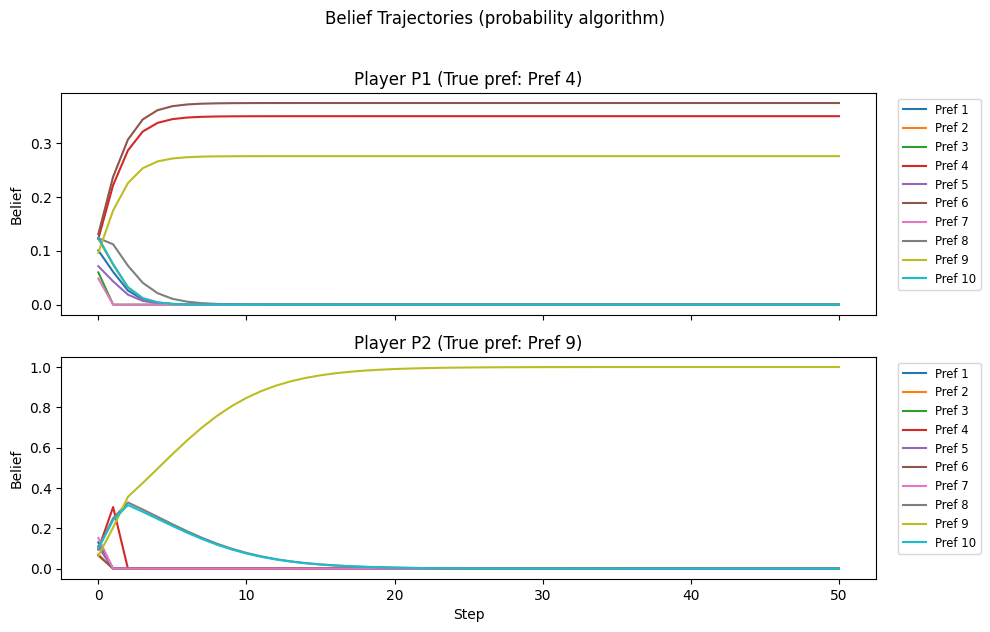

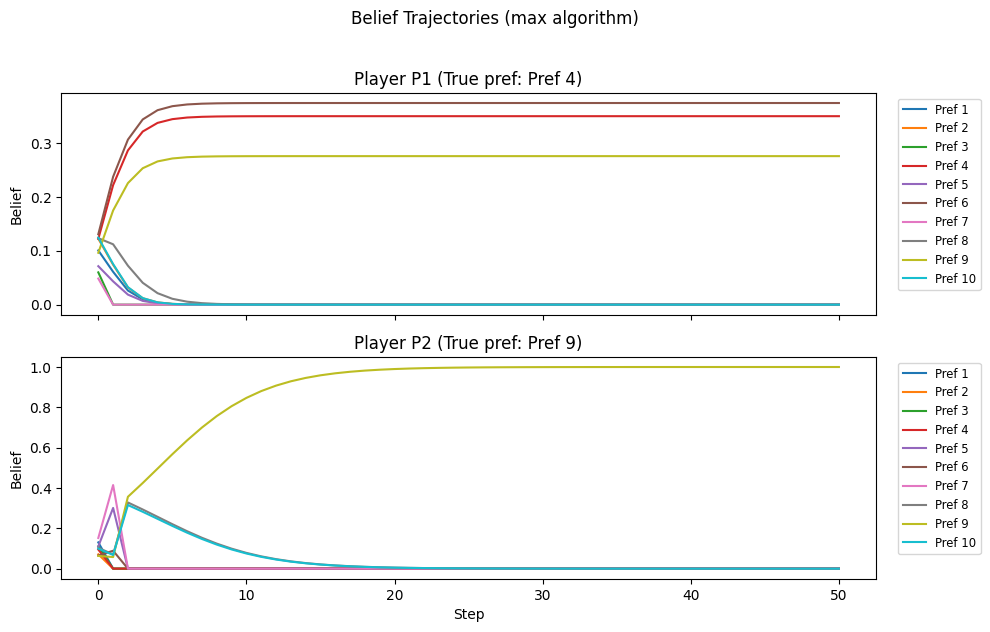

(<Figure size 1000x640 with 2 Axes>,
 array([<Axes: title={'center': 'Player P1 (True pref: Pref 4)'}, ylabel='Belief'>,
        <Axes: title={'center': 'Player P2 (True pref: Pref 9)'}, xlabel='Step', ylabel='Belief'>],
       dtype=object))

In [5]:
plot_belief_trajectories(results, player_ids, steps=steps, print_title=True, print_legend=True, simple_tilte=True, simple_legend=True)


In [6]:
# From the results, pick the final beliefs of each player, compare with true preferences, and compute pure NEs with all possible preference combinations.
result_probability_method = results['probability']
likelihood_tolerance = 1e-3

belief_trajectories, true_preferences, all_possible_preferences = result_probability_method
most_likely_preferences = {
    pid: max(
        all_possible_preferences[pid],
        key=lambda pref: belief_trajectories[pid].get(pref, [0.0])[-1] 
    )
    for pid in player_ids
}
# # Also include all preferences within likelihood tolerance
# likely_preferences_within_tolerance = {
#     pid: [
#         pref for pref in all_possible_preferences[pid]
#         if belief_trajectories[pid].get(pref, [0.0])[-1] >= belief_trajectories[pid].get(most_likely_preferences[pid], [0.0])[-1] - likelihood_tolerance
#     ]
#     for pid in player_ids
# }
# Also include all preferences within likelihood larger than tolerance
likely_preferences_within_tolerance = {
    pid: [
        pref for pref in all_possible_preferences[pid]
        if belief_trajectories[pid].get(pref, [0.0])[-1] >= likelihood_tolerance
    ]
    for pid in player_ids
}

for pid in player_ids:
    print(f"Player {pid}:")
    print(f"  True Preference: {true_preferences[pid]}")
    print(f"  Most Likely Preference: {most_likely_preferences[pid]}")
    print(f"  Preferences within tolerance:")
    for pref in likely_preferences_within_tolerance[pid]:
        print(f"    {pref}")
    print()

# Now, compute admissible pure NEs for all combinations of likely preferences
from itertools import product
admissible_pure_nes = {}
for pref_combination in product(*likely_preferences_within_tolerance.values()):
    pref_dict = {pid: pref for pid, pref in zip(player_ids, pref_combination)}
    admissible_nes = find_admissible_nash_equilibria_with_preferences(true_game, pref_dict)
    admissible_pure_nes[tuple(pref_combination)] = admissible_nes
    print(f"Preference combination: {pref_dict}")
    print(f"  Found {len(admissible_nes)} pure NEs:")
    for ne in admissible_nes:
        print(f"    {ne}")
    print()

Player P1:
  True Preference: PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M4'), ('P1M3', 'P1M4'), ('P1M2', 'P1M3')])
  Most Likely Preference: PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M3'), ('P1M2', 'P1M4'), ('P1M2', 'P1M1'), ('P1M4', 'P1M3')])
  Preferences within tolerance:
    PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M4'), ('P1M3', 'P1M4'), ('P1M2', 'P1M3')])
    PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M3'), ('P1M2', 'P1M4'), ('P1M2', 'P1M1'), ('P1M4', 'P1M3')])
    PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M4'), ('P1M1', 'P1M3'), ('P1M2', 'P1M4')])

Player P2:
  True Preference: PartialOrder(Elements: {'P2M2', 'P2M3', 'P2M4', 'P2M1'}, Hasse edges: [('P2M2', 'P2M1'), ('P2M3', 'P2M4')])
  Most Likely Preference: PartialOrder(Elements: {'P2M2', 'P2M3', 'P2M4', 'P2M1'}, Hasse edges:

In [7]:
from LearningPriority.orders import completions_of_poset
from LearningPriority.orders import PartialOrder

original_preferences = {
    pid: true_preferences[pid] for pid in player_ids
}
for pid in player_ids:
    # Convert true preferences to discrete posets, no metrics comparable
    original_preferences[pid] = PartialOrder(true_preferences[pid].elements, set())

    # Randomly add one pair of comparability to form the original preference poset
    # elements = list(true_preferences[pid].elements)
    # if len(elements) >= 2:
    #     # randomly pick two distinct elements to compare
    #     import random
    #     a, b = random.sample(elements, 2)
    #     new_relations = set([(a, b)])
    #     original_preferences[pid] = PartialOrder(true_preferences[pid].elements, new_relations)
    # else:
    #     original_preferences[pid] = PartialOrder(true_preferences[pid].elements, set())


# Compute admissible pure NEs with discrete preferences
admissible_nes_original = find_admissible_nash_equilibria_with_preferences(true_game, original_preferences)
print(f"With discrete preferences (no comparability), found {len(admissible_nes_original)} pure NEs:")
for ne in admissible_nes_original:
    print(f"    {ne}")
print()

# iterate through all combinations of completions of true preference posets for all players, take the union of admissible pure NEs found
all_admissible_nes_from_completions = set()
for completion_combination in product(*[completions_of_poset(original_preferences[pid]) for pid in player_ids]):
    completion_dict = {pid: completion for pid, completion in zip(player_ids, completion_combination)}
    admissible_nes = find_admissible_nash_equilibria_with_preferences(true_game, completion_dict)
    print(f"Completion combination: {completion_dict}")
    print(f"  Found {len(admissible_nes)} pure NEs:")
    all_admissible_nes_from_completions.update(admissible_nes)
    for ne in admissible_nes:
        print(f"    {ne}")
    print()

print(f"All admissible pure NEs from original preference combinations:")
for ne in admissible_nes_original:
    print(f"    {ne}")
print()
print(f"All admissible pure NEs from completions of original preferences:")
for ne in all_admissible_nes_from_completions:
    print(f"    {ne}")
print()

print(f"Do they match? {set(admissible_nes_original) == all_admissible_nes_from_completions}")

With discrete preferences (no comparability), found 12 pure NEs:
    ActionProfile(action_profile={'P1': 'P1A3', 'P2': 'P2A2'})
    ActionProfile(action_profile={'P1': 'P1A3', 'P2': 'P2A3'})
    ActionProfile(action_profile={'P1': 'P1A2', 'P2': 'P2A3'})
    ActionProfile(action_profile={'P1': 'P1A4', 'P2': 'P2A1'})
    ActionProfile(action_profile={'P1': 'P1A2', 'P2': 'P2A4'})
    ActionProfile(action_profile={'P1': 'P1A3', 'P2': 'P2A4'})
    ActionProfile(action_profile={'P1': 'P1A3', 'P2': 'P2A1'})
    ActionProfile(action_profile={'P1': 'P1A2', 'P2': 'P2A2'})
    ActionProfile(action_profile={'P1': 'P1A4', 'P2': 'P2A4'})
    ActionProfile(action_profile={'P1': 'P1A4', 'P2': 'P2A3'})
    ActionProfile(action_profile={'P1': 'P1A4', 'P2': 'P2A2'})
    ActionProfile(action_profile={'P1': 'P1A2', 'P2': 'P2A1'})

Completion combination: {'P1': PartialOrder(Elements: {'P1M1', 'P1M3', 'P1M2', 'P1M4'}, Hasse edges: [('P1M1', 'P1M3'), ('P1M3', 'P1M2'), ('P1M2', 'P1M4')]), 'P2': PartialOrder(E